# 55 — Adversarial evaluation benchmark (design)


## Design principles

1. **Evaluation-only:** Counterfactuals must not be added to training data; pairs are for **inference-time** robustness / fairness probes.
2. **Minimal edit:** Only declared **sensitive attributes** change; job-relevant facts (employers, skills, dates, education facts, achievements) stay the same unless an edit is technically unavoidable (then document it).
3. **Semantic validity:** The counterfactual resume must remain a plausible resume for the **same** role trajectory; no contradictory timelines or invented employers.
4. **Traceability:** Every row carries `pair_id`, `anchor_row_id`, and an `edit_rationale`; downstream runs must join predictions back to these IDs.
5. **No label leakage:** Edits must not encode the true class in a way that trivializes prediction; gold `supercategory` is **unchanged** between anchor and variant unless you are explicitly studying *label noise* (out of scope for v1).


## Sensitive attributes (v1 — allowed to vary)

| Attribute | Examples | Notes |
|-----------|----------|--------|
| City / location | City names, metro, remote vs on-site wording | Prefer substitutions from a fixed replacement table; align with 32 city list where possible. |
| Age cues | Explicit ages, graduation years that imply age | Edit **one** mechanism at a time per pair family; keep employment dates consistent or document adjustment. |
| Gendered cues | Pronouns, gendered job titles if present | Minimal surface changes; do not change job duties. |
| Name (optional) | Given name tokens | Only when paired with explicit “rest identical” diff check; avoid culturally loaded stereotypes. |


## Pair tracking schema (downstream must implement)

Each **pair** links an **anchor** (original test row) and one or more **variants** (counterfactual texts). Suggested columns:

- `pair_id`, `anchor_row_id`, `variant_id`, `split` (= `test`)
- `supercategory` (unchanged from 32)
- `attribute_edited` (`city` | `age_cue` | `gender_cue` | `name` | `multi`)
- `transform_type` (machine-readable tag, e.g. `city_substitution_nyc_to_chicago`)
- `anchor_resume_text`, `counterfactual_resume_text`
- `diff_summary` (short human-readable description)
- `edit_rationale` (why this counterfactual is valid / what was checked)
- `validation_status` (`planned` | `validated` | `rejected`)
- `provenance_note` (notebook version, seed, rule version)

**Stable keys:** Prefer hashing `(anchor_row_id, transform_type, transform_params_json)` for deterministic `variant_id` across parallel workers.


## Metrics downstream notebooks should compute

| Metric | Definition |
|--------|------------|
| **Flip rate** | Fraction of pairs where argmax predicted class changes from anchor → variant. |
| **Score delta** | Δ in logit or probability for **true** class (or full K-class vector norm). |
| **Per-attribute robustness** | Slice flip rate / Δ by `attribute_edited`. |
| **Confidence shift** | Change in entropy or max prob between anchor and variant. |
| **Agreement slice** | Restrict to pairs where anchor prediction equals gold label; measure stability under edit. |

Report **CIs** or bootstrap intervals where sample size allows; store raw scores per `pair_id` for audit.


In [1]:
"""Write adversarial benchmark design artifacts (lightweight; no model calls)."""
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

_CWD = Path.cwd()
NOTEBOOK_DIR = _CWD if _CWD.name == "notebooks" else (_CWD / "notebooks")
REPO_ROOT = NOTEBOOK_DIR.parent
RESULTS_DIR = REPO_ROOT / "notebooks" / "results" / "adversarial_eval_design"
FIG_DIR = REPO_ROOT / "figures" / "adversarial_eval_design"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_TEST = REPO_ROOT / "data" / "processed" / "english_dataset_v1" / "test.csv"
ALIGN_MANIFEST = (
    REPO_ROOT / "notebooks" / "results" / "english_dataset_alignment" / "32_english_benchmark_manifest.json"
)

BENCHMARK_SPEC = {
    "notebook": "55_adversarial_eval_design.ipynb",
    "role": "adversarial_eval_benchmark_design",
    "version": "v1_design_only",
    "canonical_alignment_notebook": "notebooks/32_english_dataset_alignment.ipynb",
    "source_split": {
        "split_name": "test",
        "csv_path_relative": "data/processed/english_dataset_v1/test.csv",
        "text_col": "resume_text",
        "label_col": "supercategory",
    },
    "scope": "evaluation_only_pairs_from_real_test_resumes",
    "training_data_policy": "Do not add counterfactuals to training; inference-only evaluation.",
    "sensitive_attributes_v1": ["city_location", "age_cue", "gendered_cue", "name_optional"],
    "forbidden_edits_summary": [
        "Change supercategory or training ontology inputs",
        "Invent employers, degrees, or dates",
        "Alter core skills/responsibilities to match stereotypes",
        "Include train/val rows in v1 pair registry",
    ],
    "optional_reference_artifact": "notebooks/results/english_dataset_alignment/32_english_city_swap_counterfactuals.csv",
    "pair_registry_columns": [
        "pair_id",
        "anchor_row_id",
        "variant_id",
        "split",
        "supercategory",
        "attribute_edited",
        "transform_type",
        "anchor_resume_text",
        "counterfactual_resume_text",
        "diff_summary",
        "edit_rationale",
        "validation_status",
        "provenance_note",
    ],
}

METRICS_SPEC = {
    "downstream_metrics": [
        {
            "name": "flip_rate",
            "description": "Fraction of pairs where predicted argmax class changes anchor→variant.",
        },
        {
            "name": "score_delta_true_class",
            "description": "Delta in logit or probability for gold supercategory.",
        },
        {
            "name": "per_attribute_robustness",
            "description": "Flip rate and score delta stratified by attribute_edited.",
        },
        {
            "name": "confidence_shift",
            "description": "Change in max prob or predictive entropy between anchor and variant.",
        },
        {
            "name": "correct_anchor_slice",
            "description": "Metrics restricted to pairs where anchor prediction equals gold label.",
        },
    ],
    "reporting": "Prefer bootstrap CIs; store per-pair logits or probs for audit.",
}

PAIR_SCHEMA_PATH = RESULTS_DIR / "pair_registry_columns.csv"

# Template with zero data rows (schema-only)
pd.DataFrame(columns=BENCHMARK_SPEC["pair_registry_columns"]).to_csv(PAIR_SCHEMA_PATH, index=False)

(RESULTS_DIR / "adversarial_benchmark_spec.json").write_text(
    json.dumps(BENCHMARK_SPEC, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
(RESULTS_DIR / "metrics_for_downstream.json").write_text(
    json.dumps(METRICS_SPEC, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

manifest = {
    "notebook": "55_adversarial_eval_design.ipynb",
    "results_dir": str(RESULTS_DIR),
    "figures_dir": str(FIG_DIR),
    "files_written": [
        "adversarial_benchmark_spec.json",
        "metrics_for_downstream.json",
        "pair_registry_columns.csv",
        "DESIGN_MANIFEST.json",
        "PLANNED_OUTPUTS.json",
    ],
    "depends_on": [
        str(PROCESSED_TEST.relative_to(REPO_ROOT)) if PROCESSED_TEST.exists() else "data/processed/english_dataset_v1/test.csv (run 32 first)",
    ],
}
(RESULTS_DIR / "DESIGN_MANIFEST.json").write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

planned = {
    "description": "Static plan for adversarial design track outputs (55). No model checkpoints stored here.",
    "results_root": "notebooks/results/adversarial_eval_design",
    "figures_root": "figures/adversarial_eval_design",
    "expected_after_run": manifest["files_written"],
    "optional_figure": "figures/adversarial_eval_design/55_adversarial_eval_flow.png",
}
(RESULTS_DIR / "PLANNED_OUTPUTS.json").write_text(
    json.dumps(planned, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Repo root:", REPO_ROOT)
print("Wrote:", RESULTS_DIR)
if ALIGN_MANIFEST.exists():
    print("Found 32 manifest:", ALIGN_MANIFEST.name)
else:
    print("Note: run 32 first — manifest missing:", ALIGN_MANIFEST)
if PROCESSED_TEST.exists():
    print("Found test split:", PROCESSED_TEST.relative_to(REPO_ROOT))
else:
    print("Note: test CSV missing — run 32 first")


Repo root: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
Wrote: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/adversarial_eval_design
Found 32 manifest: 32_english_benchmark_manifest.json
Found test split: data/processed/english_dataset_v1/test.csv


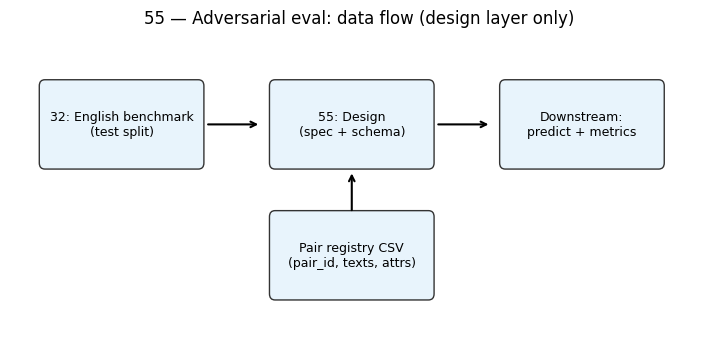

Saved /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/adversarial_eval_design/55_adversarial_eval_flow.png


In [2]:
# Optional: simple flow diagram (no heavy compute)
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib not installed; skip figure")
else:
    import matplotlib.patches as mpatches
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 4)
    ax.axis("off")
    boxes = [
        (0.5, 2.3, "32: English benchmark\n(test split)"),
        (3.8, 2.3, "55: Design\n(spec + schema)"),
        (7.1, 2.3, "Downstream:\npredict + metrics"),
        (3.8, 0.6, "Pair registry CSV\n(pair_id, texts, attrs)"),
    ]
    for x, y, t in boxes:
        ax.add_patch(mpatches.FancyBboxPatch((x, y), 2.2, 1.0, boxstyle="round,pad=0.08", ec="#333", fc="#e8f4fc"))
        ax.text(x + 1.1, y + 0.5, t, ha="center", va="center", fontsize=9)
    ax.annotate("", xy=(3.6, 2.8), xytext=(2.8, 2.8), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.annotate("", xy=(6.9, 2.8), xytext=(6.1, 2.8), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.annotate("", xy=(4.9, 2.2), xytext=(4.9, 1.65), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.set_title("55 — Adversarial eval: data flow (design layer only)")
    out = FIG_DIR / "55_adversarial_eval_flow.png"
    fig.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved", out)


## Key takeaways

- **55 is design-only:** specs, JSON manifests, and an empty pair-registry schema—no training and no mandatory GPU evaluation in this notebook.
- **Depends on 32:** the **test** split path and `supercategory` semantics come from the canonical English alignment notebook.
- **Parallel-safe:** downstream eval should write **per-model** result dirs; use deterministic `pair_id` / `variant_id` keys to avoid collisions.
- **54 is orthogonal:** the soft English slice is for class imbalance; adversarial pairs should still be built from **canonical test rows** unless you explicitly version a variant benchmark.
